In [1]:
# %% [Users with N+ actions in EVERY window]
import pickle
import numpy as np
import pandas as pd

# --- CONFIG ---
PKL_PATH = "/data/dchu/covid_masking_irl_action_v3/trajectories.pkl"
SHOCK_DATE = pd.Timestamp("2020-10-02")
WINDOW_LEN = 14
STEP_SIZE  = 2
N_WINDOWS  = 10
START_OFFSET_FIRST = -16

# --- LOAD ---
with open(PKL_PATH, "rb") as f:
    trajs = pickle.load(f)
print(f"Loaded {len(trajs):,} trajectories\n")

# --- COMPUTE PER-WINDOW COUNTS PER USER ---
n_users = len(trajs)
counts_matrix = np.zeros((n_users, N_WINDOWS), dtype=int)
pols = np.array([t["political_gen"] for t in trajs])

for u_idx, t in enumerate(trajs):
    dates = pd.to_datetime([s[0] for s in t["trajectory"]])
    for w in range(N_WINDOWS):
        w_start = SHOCK_DATE + pd.Timedelta(days=START_OFFSET_FIRST + w * STEP_SIZE)
        w_end   = w_start + pd.Timedelta(days=WINDOW_LEN)
        counts_matrix[u_idx, w] = int(((dates >= w_start) & (dates < w_end)).sum())

# --- INTERSECTION: users with >=thr in ALL windows ---
print("Users with >=N actions in EVERY one of the 10 windows:\n")
print(f"  {'thr':>4} {'all':>8} {'lib':>8} {'con':>8}")
print(f"  {'-'*4} {'-'*8} {'-'*8} {'-'*8}")

for thr in [1, 2, 3, 5, 7, 10, 15, 20]:
    mask = (counts_matrix >= thr).all(axis=1)
    n_all = mask.sum()
    n_lib = (mask & (pols == 0)).sum()
    n_con = (mask & (pols == 1)).sum()
    print(f"  >={thr:<3} {n_all:>8,} {n_lib:>8,} {n_con:>8,}")

# --- For the chosen threshold, show per-window counts on that fixed cohort ---
# Pick a threshold and inspect — change THR below
THR = 3
mask = (counts_matrix >= THR).all(axis=1)
print(f"\nFixed cohort at thr>={THR}: {mask.sum():,} users")
print(f"\nPer-window breakdown for this cohort:")
print(f"  {'W':<3} {'Range':<27} {'min':>5} {'med':>5} {'mean':>6} {'max':>5}")
for w in range(N_WINDOWS):
    w_start = SHOCK_DATE + pd.Timedelta(days=START_OFFSET_FIRST + w * STEP_SIZE)
    w_end   = w_start + pd.Timedelta(days=WINDOW_LEN)
    c = counts_matrix[mask, w]
    rng = f"{w_start.date()} to {w_end.date()}"
    print(f"  W{w:<2} {rng:<27} {c.min():>5} {int(np.median(c)):>5} {c.mean():>6.1f} {c.max():>5}")

Loaded 25,281 trajectories

Users with >=N actions in EVERY one of the 10 windows:

   thr      all      lib      con
  ---- -------- -------- --------
  >=1      5,570    4,033    1,537
  >=2      1,573    1,162      411
  >=3        609      469      140
  >=5        161      119       42
  >=7         66       48       18
  >=10        27       18        9
  >=15        13        9        4
  >=20         7        4        3

Fixed cohort at thr>=3: 609 users

Per-window breakdown for this cohort:
  W   Range                         min   med   mean   max
  W0  2020-09-16 to 2020-09-30        3     5    7.4   143
  W1  2020-09-18 to 2020-10-02        3     5    7.1   189
  W2  2020-09-20 to 2020-10-04        3     6    7.7   195
  W3  2020-09-22 to 2020-10-06        3     6    8.3   211
  W4  2020-09-24 to 2020-10-08        3     6    8.5   219
  W5  2020-09-26 to 2020-10-10        3     6    8.2   181
  W6  2020-09-28 to 2020-10-12        3     6    8.2   150
  W7  2020-09-30 to 20

In [2]:
# %% [Action frequency: how often do users typically act?]
import pickle
import numpy as np
import pandas as pd

PKL_PATH = "/data/dchu/covid_masking_irl_action_v3/trajectories.pkl"

with open(PKL_PATH, "rb") as f:
    trajs = pickle.load(f)
print(f"Loaded {len(trajs):,} trajectories\n")

# --- PER-USER STATS ---
rows = []
for t in trajs:
    dates = pd.to_datetime([s[0] for s in t["trajectory"]])
    n_actions = len(dates)
    span_days = (dates.max() - dates.min()).days + 1   # inclusive
    n_active_days = dates.normalize().nunique()        # unique days with >=1 action

    rows.append({
        "pol": t["political_gen"],
        "n_actions": n_actions,
        "span_days": span_days,
        "n_active_days": n_active_days,
        "actions_per_day_span": n_actions / span_days,           # over full span
        "actions_per_day_active": n_actions / n_active_days,     # on days they DO act
        "actions_per_week_span": n_actions / span_days * 7,
        "active_day_rate": n_active_days / span_days,            # fraction of days they're active
    })

df = pd.DataFrame(rows)

# --- OVERALL ---
print("=" * 70)
print("OVERALL (all users)")
print("=" * 70)
print(f"\nTotal actions per user (full year):")
print(df["n_actions"].describe(percentiles=[.25, .5, .75, .9, .95]).round(1))

print(f"\nActive span (first to last action, days):")
print(df["span_days"].describe(percentiles=[.25, .5, .75, .9, .95]).round(1))

print(f"\nActions per day (over span):")
print(df["actions_per_day_span"].describe(percentiles=[.25, .5, .75, .9, .95]).round(3))

print(f"\nActions per week (over span):")
print(df["actions_per_week_span"].describe(percentiles=[.25, .5, .75, .9, .95]).round(2))

print(f"\nActive day rate (fraction of span-days with >=1 action):")
print(df["active_day_rate"].describe(percentiles=[.25, .5, .75, .9, .95]).round(3))

print(f"\nActions on days they DO act (median actions on active days):")
print(df["actions_per_day_active"].describe(percentiles=[.25, .5, .75, .9, .95]).round(2))

# --- BY POLITICAL GROUP ---
print("\n" + "=" * 70)
print("BY GROUP (median values)")
print("=" * 70)
print(f"\n{'group':<14} {'n_act':>8} {'span_d':>8} {'act/day':>9} {'act/wk':>8} {'active_rt':>10}")
for pol, lab in [(0, "Liberal"), (1, "Conservative")]:
    sub = df[df["pol"] == pol]
    print(f"{lab:<14} "
          f"{int(sub['n_actions'].median()):>8} "
          f"{int(sub['span_days'].median()):>8} "
          f"{sub['actions_per_day_span'].median():>9.3f} "
          f"{sub['actions_per_week_span'].median():>8.2f} "
          f"{sub['active_day_rate'].median():>10.3f}")

# --- TYPICAL GAP BETWEEN ACTIONS ---
print("\n" + "=" * 70)
print("TYPICAL GAP BETWEEN CONSECUTIVE ACTIONS (per user, then aggregated)")
print("=" * 70)
median_gaps = []
for t in trajs:
    if len(t["trajectory"]) < 2:
        continue
    dates = pd.to_datetime([s[0] for s in t["trajectory"]])
    gaps = np.diff(dates.values).astype("timedelta64[D]").astype(int)
    median_gaps.append(np.median(gaps))
median_gaps = np.array(median_gaps)
print(f"\nDistribution of per-user MEDIAN gap (days between actions):")
print(pd.Series(median_gaps).describe(percentiles=[.25, .5, .75, .9, .95]).round(2))

Loaded 25,281 trajectories

OVERALL (all users)

Total actions per user (full year):
count    25281.0
mean        20.8
std         23.3
min         10.0
25%         12.0
50%         15.0
75%         22.0
90%         35.0
95%         48.0
max       1300.0
Name: n_actions, dtype: float64

Active span (first to last action, days):
count    25281.0
mean       169.5
std         49.9
min          1.0
25%        147.0
50%        176.0
75%        197.0
90%        225.0
95%        245.0
max        341.0
Name: span_days, dtype: float64

Actions per day (over span):
count    25281.000
mean         0.159
std          0.543
min          0.032
25%          0.072
50%          0.096
75%          0.143
90%          0.227
95%          0.333
max         25.000
Name: actions_per_day_span, dtype: float64

Actions per week (over span):
count    25281.00
mean         1.11
std          3.80
min          0.23
25%          0.51
50%          0.67
75%          1.00
90%          1.59
95%          2.33
max        1

In [8]:
# %% [Users with N+ actions in EVERY window — adds T-6 endpoint]
import pickle
import numpy as np
import pandas as pd

PKL_PATH = "/data/dchu/covid_masking_irl_action_v3/trajectories.pkl"
SHOCK_DATE = pd.Timestamp("2020-10-02")
WINDOW_LEN = 30
end_offsets = [-6, -3, 0, 3, 6, 9, 12]
N_WINDOWS = len(end_offsets)

with open(PKL_PATH, "rb") as f:
    trajs = pickle.load(f)
print(f"Loaded {len(trajs):,} trajectories\n")

n_users = len(trajs)
counts_matrix = np.zeros((n_users, N_WINDOWS), dtype=int)
pols = np.array([t["political_gen"] for t in trajs])

for u_idx, t in enumerate(trajs):
    dates = pd.to_datetime([s[0] for s in t["trajectory"]])
    for w, off in enumerate(end_offsets):
        w_end   = SHOCK_DATE + pd.Timedelta(days=off)
        w_start = w_end - pd.Timedelta(days=WINDOW_LEN)
        counts_matrix[u_idx, w] = int(((dates >= w_start) & (dates < w_end)).sum())

print("Window boundaries:")
print(f"  {'W':<3} {'end':<10} {'range':<27}")
for w, off in enumerate(end_offsets):
    w_end   = SHOCK_DATE + pd.Timedelta(days=off)
    w_start = w_end - pd.Timedelta(days=WINDOW_LEN)
    print(f"  W{w:<2} T{off:+d}  ({w_end.date()})  {w_start.date()} to {w_end.date()}")

print(f"\nUsers with >=N actions in EVERY one of the {N_WINDOWS} windows:\n")
print(f"  {'thr':>4} {'all':>8} {'lib':>8} {'con':>8}")
print(f"  {'-'*4} {'-'*8} {'-'*8} {'-'*8}")
for thr in [1, 2, 3, 5, 7, 10, 15, 20]:
    mask = (counts_matrix >= thr).all(axis=1)
    print(f"  >={thr:<3} {mask.sum():>8,} "
          f"{(mask & (pols==0)).sum():>8,} "
          f"{(mask & (pols==1)).sum():>8,}")

THR = 7
mask = (counts_matrix >= THR).all(axis=1)
print(f"\nFixed cohort at thr>={THR}: {mask.sum():,} users")
if mask.sum() > 0:
    print(f"\nPer-window action counts for this cohort:")
    print(f"  {'W':<3} {'end':<6} {'min':>5} {'med':>5} {'mean':>6} {'max':>5}")
    for w, off in enumerate(end_offsets):
        c = counts_matrix[mask, w]
        print(f"  W{w:<2} T{off:+<4d} {c.min():>5} {int(np.median(c)):>5} {c.mean():>6.1f} {c.max():>5}")

Loaded 25,281 trajectories

Window boundaries:
  W   end        range                      
  W0  T-6  (2020-09-26)  2020-08-27 to 2020-09-26
  W1  T-3  (2020-09-29)  2020-08-30 to 2020-09-29
  W2  T+0  (2020-10-02)  2020-09-02 to 2020-10-02
  W3  T+3  (2020-10-05)  2020-09-05 to 2020-10-05
  W4  T+6  (2020-10-08)  2020-09-08 to 2020-10-08
  W5  T+9  (2020-10-11)  2020-09-11 to 2020-10-11
  W6  T+12  (2020-10-14)  2020-09-14 to 2020-10-14

Users with >=N actions in EVERY one of the 7 windows:

   thr      all      lib      con
  ---- -------- -------- --------
  >=1     15,959   11,780    4,179
  >=2      8,918    6,562    2,356
  >=3      4,872    3,570    1,302
  >=5      1,756    1,298      458
  >=7        804      601      203
  >=10       347      260       87
  >=15       123       87       36
  >=20        72       50       22

Fixed cohort at thr>=7: 804 users

Per-window action counts for this cohort:
  W   end      min   med   mean   max
  W0  T-6++     7    11   14.4   395


In [14]:
# %% [Build cohort pkl: users with >=7 actions in every shock window (7 windows)]
import pickle
import os
import numpy as np
import pandas as pd

# --- CONFIG ---
SRC_PKL = "/data/dchu/covid_masking_irl_action_v3/trajectories.pkl"
OUT_DIR = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/rolling_window_around_shock"
OUT_PKL = os.path.join(OUT_DIR, "trajectories_cohort_thr7_7win.pkl")

SHOCK_DATE = pd.Timestamp("2020-10-02")
WINDOW_LEN = 30
end_offsets = [-6, -3, 0, 3, 6, 9, 12]
THR = 7

# --- LOAD ---
with open(SRC_PKL, "rb") as f:
    trajs = pickle.load(f)
print(f"Loaded {len(trajs):,} trajectories from {SRC_PKL}")

# --- FILTER COHORT ---
keep = []
for t in trajs:
    dates = pd.to_datetime([s[0] for s in t["trajectory"]])
    ok = True
    for off in end_offsets:
        w_end   = SHOCK_DATE + pd.Timedelta(days=off)
        w_start = w_end - pd.Timedelta(days=WINDOW_LEN)
        n_in = int(((dates >= w_start) & (dates < w_end)).sum())
        if n_in < THR:
            ok = False
            break
    if ok:
        keep.append(t)

print(f"\nCohort (>={THR} actions in every one of {len(end_offsets)} windows): {len(keep):,} users")
n_lib = sum(1 for t in keep if t["political_gen"] == 0)
n_con = sum(1 for t in keep if t["political_gen"] == 1)
print(f"  Liberal:      {n_lib:,}")
print(f"  Conservative: {n_con:,}")

# --- SAVE ---
os.makedirs(OUT_DIR, exist_ok=True)
with open(OUT_PKL, "wb") as f:
    pickle.dump(keep, f)
print(f"\nSaved to {OUT_PKL}")

# --- METADATA ---
meta = {
    "src_pkl": SRC_PKL,
    "shock_date": str(SHOCK_DATE.date()),
    "window_len": WINDOW_LEN,
    "n_windows": len(end_offsets),
    "end_offsets": end_offsets,
    "threshold": THR,
    "n_users": len(keep),
    "n_liberal": n_lib,
    "n_conservative": n_con,
    "windows": [
        {
            "w": w,
            "end_offset": off,
            "start": str((SHOCK_DATE + pd.Timedelta(days=off) - pd.Timedelta(days=WINDOW_LEN)).date()),
            "end":   str((SHOCK_DATE + pd.Timedelta(days=off)).date()),
        }
        for w, off in enumerate(end_offsets)
    ],
}
meta_path = os.path.join(OUT_DIR, "cohort_thr7_7win_meta.txt")
with open(meta_path, "w") as f:
    for k, v in meta.items():
        f.write(f"{k}: {v}\n")
print(f"Metadata to {meta_path}")

Loaded 25,281 trajectories from /data/dchu/covid_masking_irl_action_v3/trajectories.pkl

Cohort (>=7 actions in every one of 7 windows): 804 users
  Liberal:      601
  Conservative: 203

Saved to /nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/rolling_window_around_shock/trajectories_cohort_thr7_7win.pkl
Metadata to /nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/rolling_window_around_shock/cohort_thr7_7win_meta.txt


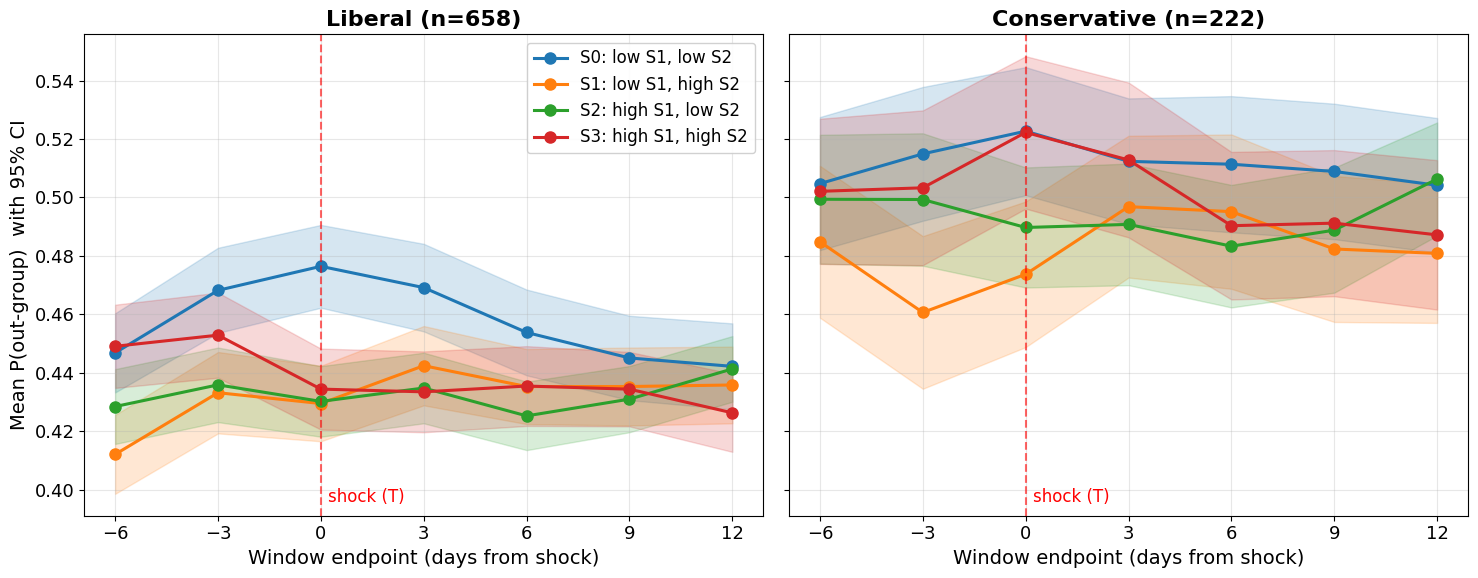

In [15]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

OUT_DIR = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/rolling_window_around_shock"
END_OFFSETS = [-6, -3, 0, 3, 6, 9, 12]
N_STATES = 4

# Load
dfs = []
for w, off in enumerate(END_OFFSETS):
    p = os.path.join(OUT_DIR, f"rolling_irl_thr7_window_{w}_T{off:+d}.parquet")
    dfs.append(pd.read_parquet(p))
df = pd.concat(dfs, ignore_index=True)

# Labels matching your convention
state_labels = {
    0: "S0: low S1, low S2",
    1: "S1: low S1, high S2",
    2: "S2: high S1, low S2",
    3: "S3: high S1, high S2",
}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

plt.rcParams.update({"font.size": 14})
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for ax, (pol, lab) in zip(axes, [(0, "Liberal"), (1, "Conservative")]):
    sub = df[df["pol"] == pol]
    n_users = sub["uid"].nunique()
    for s in range(N_STATES):
        agg = sub.groupby("end_offset")[f"policy_out_s{s}"].agg(["mean", "sem"])
        # 95% CI band
        ci = 1.96 * agg["sem"]
        ax.plot(agg.index, agg["mean"], color=colors[s], marker="o",
                markersize=8, linewidth=2.2, label=state_labels[s])
        ax.fill_between(agg.index, agg["mean"] - ci, agg["mean"] + ci,
                        color=colors[s], alpha=0.18)
    ax.axvline(0, color="red", ls="--", alpha=0.6, linewidth=1.5)
    ax.text(0.2, ax.get_ylim()[1] if False else 0.02, "shock (T)",
            color="red", fontsize=12, transform=ax.get_xaxis_transform(),
            va="bottom")
    ax.set_title(f"{lab} (n={n_users})", fontsize=16, fontweight="bold")
    ax.set_xlabel("Window endpoint (days from shock)", fontsize=14)
    ax.set_xticks(END_OFFSETS)
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Mean P(out-group)  with 95% CI", fontsize=14)
axes[0].legend(fontsize=12, loc="best", framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "policy_shift.png"), dpi=120, bbox_inches="tight")
plt.show()

In [12]:
# Pivot to wide: rows=uid, cols=(window, state)
import os, numpy as np, pandas as pd

OUT_DIR = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/rolling_window_around_shock"
END_OFFSETS = [-6, -3, 0, 3, 6, 9, 12]
N_STATES = 4

dfs = [pd.read_parquet(os.path.join(OUT_DIR, f"rolling_irl_thr7_window_{w}_T{off:+d}.parquet"))
       for w, off in enumerate(END_OFFSETS)]
df = pd.concat(dfs, ignore_index=True)

policy_cols = [f"policy_out_s{s}" for s in range(N_STATES)]

# Pre = W0+W1 (T-6, T-3), Post = last 2 windows (T+9, T+12)
pre = df[df["end_offset"].isin([-6, -3])].groupby("uid")[policy_cols].mean()
post = df[df["end_offset"].isin([9, 12])].groupby("uid")[policy_cols].mean()
shift = (post - pre)
shift["pol"] = df.groupby("uid")["pol"].first()
shift["l1_shift"] = shift[policy_cols].abs().sum(axis=1)
shift["mean_shift"] = shift[policy_cols].mean(axis=1)  # signed: + = more out-group

# Top movers
print("Top 20 BIGGEST shifters (any direction):")
print(shift.nlargest(20, "l1_shift"))

print("\nTop 10 most TOWARD out-group:")
print(shift.nlargest(10, "mean_shift"))

print("\nTop 10 most TOWARD in-group:")
print(shift.nsmallest(10, "mean_shift"))

Top 20 BIGGEST shifters (any direction):
                     policy_out_s0  policy_out_s1  policy_out_s2  \
uid                                                                
318817669                -0.659221       0.506423       0.372659   
1145353162808864768      -0.388822       0.638951      -0.242114   
379185264                -0.733790      -0.316227       0.176554   
4730638037               -0.305765       0.633202       0.459105   
2567292679               -0.650562       0.445676       0.002032   
2750799759               -0.388927       0.542689       0.159072   
813156341346770944        0.514630      -0.046460      -0.447924   
889961643857326082        0.105255      -0.549237      -0.123250   
1169317197799464961      -0.559342      -0.311564       0.237648   
891885222375165952       -0.593587      -0.242717      -0.502120   
2598357146                0.340987      -0.201582       0.379301   
950380857545646080        0.309746       0.500050      -0.259465   
3241451

In [16]:
import pandas as pd, glob, numpy as np, os

DATA_DIR = "/data/dchu/covid_masking"
target_uids = [
    318817669, 1145353162808864768, 379185264, 4730638037, 2567292679,
    2750799759, 813156341346770944, 889961643857326082, 1169317197799464961,
    891885222375165952, 2230247461, 977570219504709632, 2502938032,
    1262275483, 183753455,
]
target_set = set(str(u) for u in target_uids)

# Cast and filter across all parquets
records = []
for f in sorted(glob.glob(os.path.join(DATA_DIR, "masking_2020-*.parquet"))):
    df = pd.read_parquet(f, columns=["userid", "screen_name", "date", "text",
                                      "tweet_type", "stance_bin", "political_gen"])
    df["userid"] = df["userid"].astype("int64").astype(str)
    sub = df[df["userid"].isin(target_set)]
    if len(sub):
        records.append(sub)

all_tweets = pd.concat(records, ignore_index=True)
all_tweets["date"] = pd.to_datetime(all_tweets["date"], errors="coerce")
print(f"Total tweets from target users: {len(all_tweets):,}")

# Per-user summary
summary = all_tweets.groupby("userid").agg(
    screen_name=("screen_name", "first"),
    n_tweets=("text", "count"),
    pol=("political_gen", "first"),
    pro_mask_rate=("stance_bin", "mean"),
    first_date=("date", "min"),
    last_date=("date", "max"),
).reset_index()
print(summary)

/tmp/ipykernel_1795807/4107563790.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_tweets["date"] = pd.to_datetime(all_tweets["date"], errors="coerce")


Total tweets from target users: 2,642
                 userid      screen_name  n_tweets  pol  pro_mask_rate  \
0   1145353162808864768  NeverGiveUpNev3       124  0.0       0.959677   
1   1169317197799464961    NickB09121299       113  0.0       0.991150   
2            1262275483           IWPCHI        64  0.0       0.187500   
3             183753455     damonbethea1       297  0.0       0.983165   
4            2230247461      islandtelHI       153  0.0       1.000000   
5            2502938032        Adita1212       175  0.0       0.982857   
6            2567292679    fredwalton216       102  0.0       0.960784   
7            2750799759   pushandpulljlm       500  0.0       0.952000   
8             318817669       WilliamRuh       192  0.0       0.885417   
9             379185264      michgorlevy       326  0.0       1.000000   
10           4730638037       jograce777        50  1.0       0.480000   
11   813156341346770944          skysira       285  1.0       0.256140   
